In [1]:
import pyodbc
import pandas as pd
import numpy as np

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

## produce entity country list

In [197]:
df = pd.read_csv('key dataframe\\emir_dataframe.csv')

In [7]:
hedge_funds = pd.read_csv('key dataframe\\overlap_hedge_funds.csv')

In [8]:
hf_overlap = tuple(hedge_funds['entity_id'].unique())

In [20]:
# Data prep
query = f"""


WITH country_counts AS (
    SELECT 
        other_cpty_id AS entity_id,
        other_cpty_country AS fund_country,
        COUNT(*) AS cnt,
        ROW_NUMBER() OVER (
            PARTITION BY other_cpty_id 
            ORDER BY COUNT(*) DESC, other_cpty_country
        ) AS rn
    FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
    WHERE reference_period >= '2021-01-04'
    AND reference_period <= '2024-04-29'
    AND notional < 1e18
    AND asset_class = 'INTR'
    AND contract_type = 'FUTR'
    AND notional > 0
    AND notional_currency1 IN ("EUR", "USD")
    AND LEFT(product_clssfctn, 3) = 'FFD'
    AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
    AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
    AND MONTH(maturity_date) IN (3, 6, 9, 12)
    AND (s_entity.sector = 'IF' OR s_entity.sector = 'OFI' OR s_entity.sector = 'OTHR' OR other_cpty_id_esa_sector = 'S124' OR other_cpty_id IN {hf_overlap})
    AND other_cpty_country IS NOT NULL
    GROUP BY other_cpty_id, other_cpty_country
)
SELECT entity_id, fund_country
FROM country_counts
WHERE rn = 1


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_1776\2329737089.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [21]:
df_emir_old.head()

,entity_id,fund_country
0,0000015039080,IT
1,0000019595781,IT
2,0000020435541,IT
3,0000020883661,IT
4,0000021268701,IT


In [18]:
# Data prep
query = f"""


WITH country_counts AS (
    SELECT 
        other_cpty_id AS entity_id,
        other_cpty_country AS fund_country,
        COUNT(*) AS cnt,
        ROW_NUMBER() OVER (
            PARTITION BY other_cpty_id 
            ORDER BY COUNT(*) DESC, other_cpty_country
        ) AS rn
    FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
    WHERE reference_period >= '2024-04-29'
    AND reference_period <= '2025-12-31'
    AND notional_leg1 < 1e18
    AND asset_class = 'INTR'
    AND contract_type = 'FUTR'
    AND notional_leg1 > 0
    AND notional_leg1_currency IN ("EUR", "USD")
    AND LEFT(product_cfi, 3) = 'FFD'
    AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
    AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
    AND MONTH(maturity_date) IN (3, 6, 9, 12)
    AND (s_entity.sector = 'IF' OR other_cpty_id_esa_sector_riad = 'S124' OR other_cpty_id IN {hf_overlap})
    AND other_cpty_country IS NOT NULL
    GROUP BY other_cpty_id, other_cpty_country
)
SELECT entity_id, fund_country
FROM country_counts
WHERE rn = 1


"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_1776\2636312283.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [19]:
df_emir_refit.head()

,entity_id,fund_country
0,2138003BUF31DA9WE195,NL
1,213800R84TOP7WXDMI25,LU
2,213800ZGC5HVONNMBP97,LU
3,222100GH7XKDGO3GLZ60,LU
4,259400UDVNM7BTIFHN45,PL


In [22]:
df_emir_old['fund_country'].value_counts()

fund_country
DE    3064
IT    2691
LU    2367
FR    1861
ES    1450
      ... 
KZ       1
SA       1
AZ       1
CL       1
BH       1
Name: count, Length: 64, dtype: int64

In [23]:
df_emir_refit['fund_country'].value_counts()

fund_country
FR    710
LU    579
DE    357
ES    165
PL     93
NL     57
BE     57
IE     56
DK     40
KY     32
SE     29
IT     25
PT     23
NO     11
AT      7
CH      6
MT      5
GB      5
SK      5
FI      4
EE      4
AU      4
CA      3
GG      2
LI      2
VG      2
MX      2
MC      1
BM      1
NZ      1
Name: count, dtype: int64

In [24]:
import pandas as pd

# Combine both sources, tracking origin for debugging
combined = pd.concat([
    df_emir_old.assign(source='old'),
    df_emir_refit.assign(source='refit')
], ignore_index=True)

# Find entities with conflicting countries across the two sources
conflicts = (
    combined.groupby('entity_id')['fund_country']
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

print(f"Entities with conflicting countries: {len(conflicts)}")
if len(conflicts) > 0:
    print(combined[combined['entity_id'].isin(conflicts)].sort_values('entity_id'))

Entities with conflicting countries: 7
                  entity_id fund_country source
9062   213800K9BG26TTIOWA66           IE    old
15795  213800K9BG26TTIOWA66           FR  refit
8830   54930051VFLF7MTO7E08           LU    old
15370  54930051VFLF7MTO7E08           IE  refit
3718   549300DUBGP6QQFBGR26           LU    old
15953  549300DUBGP6QQFBGR26           IE  refit
841    549300IOJEZBE5GAM019           LU    old
15034  549300IOJEZBE5GAM019           IE  refit
11334  549300MAHX2I6F4TNN85           LU    old
15041  549300MAHX2I6F4TNN85           IE  refit
6264   549300S28JIB177JCC17           LU    old
16096  549300S28JIB177JCC17           IE  refit
10024  9695009TXODHXCG8FU32           FR    old
16126  9695009TXODHXCG8FU32           LU  refit


In [25]:
# Option C: prefer refit, but fall back to old if refit is missing
df_final = (
    df_emir_refit
    .set_index('entity_id')
    .combine_first(df_emir_old.set_index('entity_id'))
    .reset_index()
)


In [26]:
df_final.head()

,entity_id,fund_country
0,0000000034125,IT
1,0000000034336,IT
2,0000000039845,IT
3,0000000041427,IT
4,0000000279410,IT


In [27]:
len(df)

17853635

In [198]:
df = df.merge(df_final, on = 'entity_id', how = 'left')

In [199]:
len(df)

17853635

In [30]:
df.head()

,Unnamed: 0,business_date,entity_id,currency,futures_contract,maturity_month,is_bond_future,long_futures,short_futures,sftds_overlap,futures_identifier,fund_country
0,0,2021-01-04,0000000034125,EUR,btp_03_21,03_21,1,0.0,303340.0,0.0,IKH21,IT
1,1,2021-01-04,0000000034336,EUR,btp_03_21,03_21,1,0.0,18210600.0,0.0,IKH21,IT
2,2,2021-01-04,0000012739505,EUR,btp_03_21,03_21,1,151480.0,151540.0,0.0,IKH21,IT
3,3,2021-01-04,0000019534644,EUR,bund_03_21,03_21,1,709530.0,709490.0,0.0,RXH21,IT
4,4,2021-01-04,0000019537875,EUR,bund_03_21,03_21,1,4790030.0,5150780.0,0.0,RXH21,IT


In [155]:
df['fund_country'].fillna('Other', inplace = True)

In [156]:
df['fund_country'].value_counts(dropna=False)

fund_country
DE       4379847
LU       4120162
FR       2635499
IT       1746126
Other    1040133
          ...   
SA            70
IS            38
TH            28
KZ            19
TW             1
Name: count, Length: 62, dtype: int64

In [162]:
sftds_hf = pd.read_csv("key dataframe\\sftds_hedgefunds.csv")

In [164]:
sftds_entities = tuple(sftds_hf['0'].unique())

In [168]:
# data prep
query = f"""

WITH borrower_side AS (
    SELECT 
        s.borrower_id AS entity_id, 
        s.borrower_country_residence AS fund_country
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
    WHERE s.nominal_ccy IN ('EUR', 'USD')
      AND s.business_date <= '2025-10-01'
      AND s.borrower_id IN {sftds_entities}
      AND s.borrower_country_residence IS NOT NULL
),
lender_side AS (
    SELECT 
        s.lender_id AS entity_id, 
        s.lender_country_residence AS fund_country
    FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
    WHERE s.nominal_ccy IN ('EUR', 'USD')
      AND s.business_date <= '2025-10-01'
      AND s.lender_id IN {sftds_entities}
      AND s.lender_country_residence IS NOT NULL
),
combined AS (
    SELECT entity_id, fund_country FROM borrower_side
    UNION ALL
    SELECT entity_id, fund_country FROM lender_side
),
country_counts AS (
    SELECT 
        entity_id,
        fund_country,
        ROW_NUMBER() OVER (
            PARTITION BY entity_id 
            ORDER BY COUNT(*) DESC, fund_country
        ) AS rn
    FROM combined
    GROUP BY entity_id, fund_country
)
SELECT entity_id, fund_country
FROM country_counts
WHERE rn = 1

"""

df_sftds = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_1776\3013032345.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sftds = pd.read_sql_query(query, cnxn)


In [169]:
df_sftds.head()

,entity_id,fund_country
0,2138001PQ68WG43M5I05,KY
1,21380081MZI87Z1WS280,GB
2,254900C8RU2Z3368SC56,KY
3,254900FSGAH4RX71LL29,KY
4,254900YDHRIVFROLV916,KY


In [170]:
df_sftds_full = pd.read_csv("key dataframe\\sftds_dataframe.csv")

In [171]:
df_sftds_full = df_sftds_full.merge(df_sftds, on = 'entity_id', how = 'left')

In [173]:
df_sftds_full['fund_country'].fillna('Other', inplace = True)

In [174]:
sftds_combination = df_sftds_full[['entity_id', 'fund_country']].drop_duplicates()

In [159]:
emir_combination = df[['entity_id', 'fund_country']].drop_duplicates()

In [175]:
combined = (
    pd.concat([sftds_combination, emir_combination], ignore_index=True)
    .drop_duplicates(subset='entity_id', keep='first')
    .reset_index(drop=True)
)

In [177]:
combined.to_csv('key dataframe\\fund_countries.csv', index = False)

## Germany

In [21]:
df = pd.read_csv('key dataframe\\emir_dataframe.csv', index_col= 0)

In [22]:
countries = pd.read_csv('key dataframe\\fund_countries.csv')

In [23]:
df = df.merge(countries, on = 'entity_id', how = 'left')

In [24]:
df_de = df[(df['is_bond_future'] == 1) & (df['currency'] == 'EUR') & (df['futures_contract'].str[:3].isin(['bun', 'sch', 'bob', 'bux'])) & (df['long_futures'] <= 1e10) & (df['short_futures'] <= 1e10)]

In [25]:
df_de['fund_country'].fillna('Other', inplace = True)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_47228\1661804921.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_de['fund_country'].fillna('Other', inplace = True)


In [26]:
df_de = df_de[['business_date', 'fund_country', 'long_futures', 'short_futures']].groupby(['business_date', 'fund_country']).sum().reset_index()

In [27]:
df_de['net_pos'] = (df_de['long_futures'] - df_de['short_futures'])/1e9

In [28]:
df_de['business_date'] = pd.to_datetime(df_de['business_date'])

In [29]:
# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

# Countries shown individually
NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

df_de = df_de.copy()
df_de['group'] = df_de['fund_country'].map(bucket)

In [ ]:
df_de.to_csv('Data\\germany_fund_location.csv')

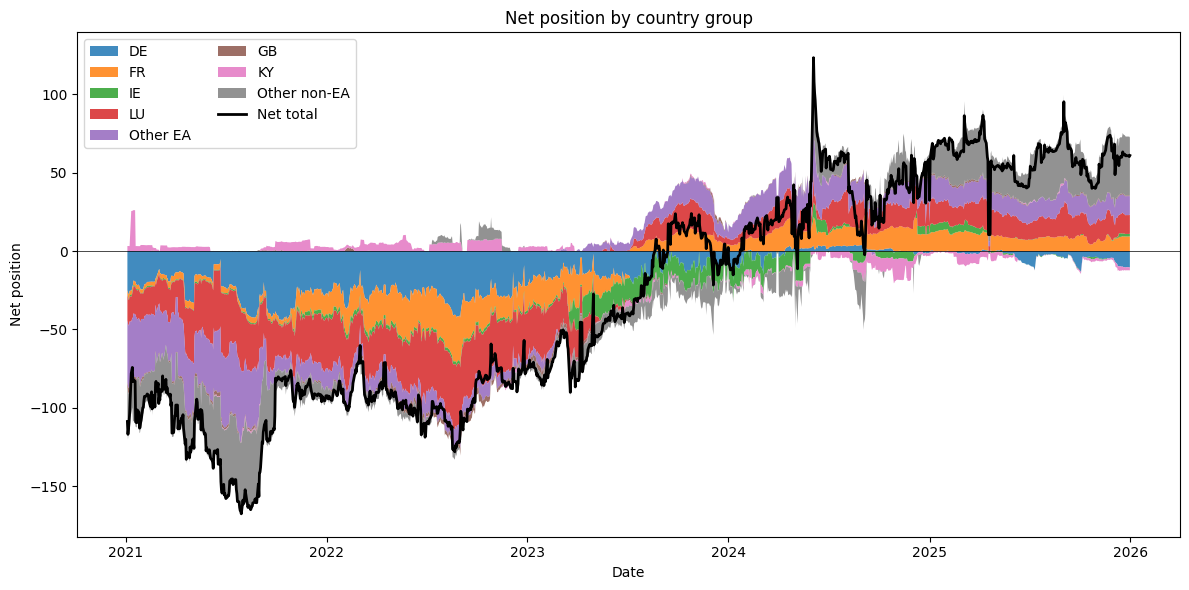

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Pivot to wide format, with a fixed column order
order = ['DE', 'FR', 'IE', 'LU', 'Other EA', 'GB', 'KY', 'Other non-EA']
pivot = (
    df_de.pivot_table(
        index='business_date',
        columns='group',
        values='net_pos',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=order, fill_value=0)
    .sort_index()
)

# Split positive and negative contributions
pos = pivot.clip(lower=0)
neg = pivot.clip(upper=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Use a consistent color per group across both stacks
colors = plt.cm.tab10.colors[:len(order)]

ax.stackplot(pos.index, pos.T, labels=pos.columns, colors=colors, alpha=0.85)
ax.stackplot(neg.index, neg.T, colors=colors, alpha=0.85)  # no labels, shared colors

# Net total line
total = pivot.sum(axis=1)
ax.plot(total.index, total, color='black', linewidth=2, label='Net total')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Net position')
ax.set_title('Net position by country group')
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

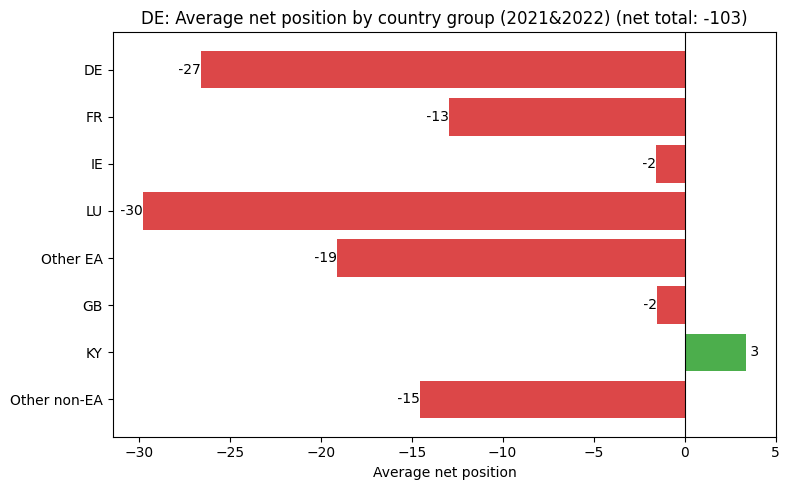

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']
ORDER = ['DE', 'FR', 'IE', 'LU', 'Other EA', 'GB', 'KY', 'Other non-EA']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

# Group into buckets and average over time
df_plot = df_de[df_de['business_date']< '2023-01-01'].copy()
df_plot['group'] = df_plot['fund_country'].map(bucket)

# First sum across countries within each (date, group), then average across dates
summary = (
    df_plot.groupby(['business_date', 'group'])['net_pos'].sum()
    .groupby('group').mean()
    .reindex(ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['tab:green' if v >= 0 else 'tab:red' for v in summary]
ax.barh(summary.index, summary.values, color=colors, alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Average net position')
ax.set_title(f'DE: Average net position by country group (2021&2022) (net total: {summary.sum():,.0f})')

for i, v in enumerate(summary.values):
    ax.text(v, i, f' {v:,.0f}', va='center',
            ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.show()

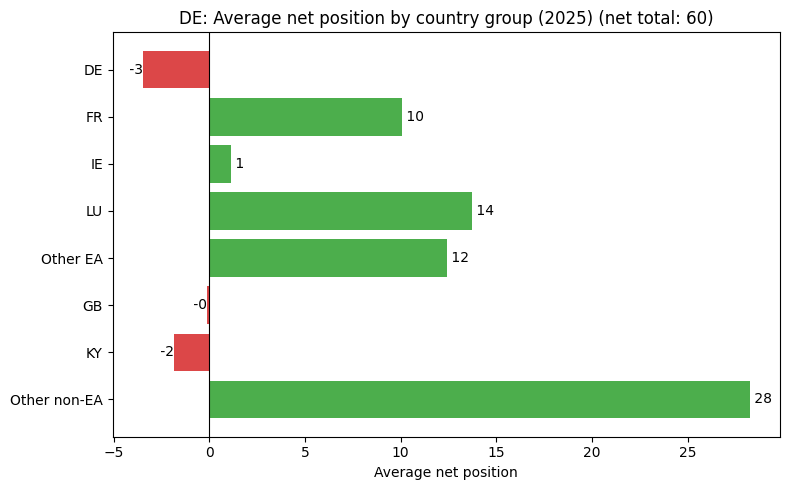

In [215]:
import matplotlib.pyplot as plt
import pandas as pd

# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']
ORDER = ['DE', 'FR', 'IE', 'LU', 'Other EA', 'GB', 'KY', 'Other non-EA']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

# Group into buckets and average over time
df_plot = df_de[df_de['business_date'] > '2025-01-01'].copy()
df_plot['group'] = df_plot['fund_country'].map(bucket)

# First sum across countries within each (date, group), then average across dates
summary = (
    df_plot.groupby(['business_date', 'group'])['net_pos'].sum()
    .groupby('group').mean()
    .reindex(ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['tab:green' if v >= 0 else 'tab:red' for v in summary]
ax.barh(summary.index, summary.values, color=colors, alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Average net position')
ax.set_title(f'DE: Average net position by country group (2025) (net total: {summary.sum():,.0f})')

for i, v in enumerate(summary.values):
    ax.text(v, i, f' {v:,.0f}', va='center',
            ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.show()

## US

In [32]:
df = pd.read_csv('key dataframe\\emir_dataframe.csv', index_col= 0)

In [33]:
countries = pd.read_csv('key dataframe\\fund_countries.csv')

In [34]:
df = df.merge(countries, on = 'entity_id', how = 'left')

In [35]:
df_us = df[(df['is_bond_future'] == 1) & (df['currency'] == 'USD') & (df['long_futures'] <= 1e10) & (df['short_futures'] <= 1e10)]

In [36]:
df_us['fund_country'].fillna('Other', inplace = True)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_47228\259036780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_us['fund_country'].fillna('Other', inplace = True)


In [37]:
df_us = df_us[['business_date', 'fund_country', 'long_futures', 'short_futures']].groupby(['business_date', 'fund_country']).sum().reset_index()

In [38]:
df_us['net_pos'] = (df_us['long_futures'] - df_us['short_futures'])/1e9

In [39]:
df_us['business_date'] = pd.to_datetime(df_us['business_date'])

In [40]:
# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

# Countries shown individually
NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

df_us['group'] = df_us['fund_country'].map(bucket)

In [41]:
df_us.to_csv('Data\\us_fund_location.csv')

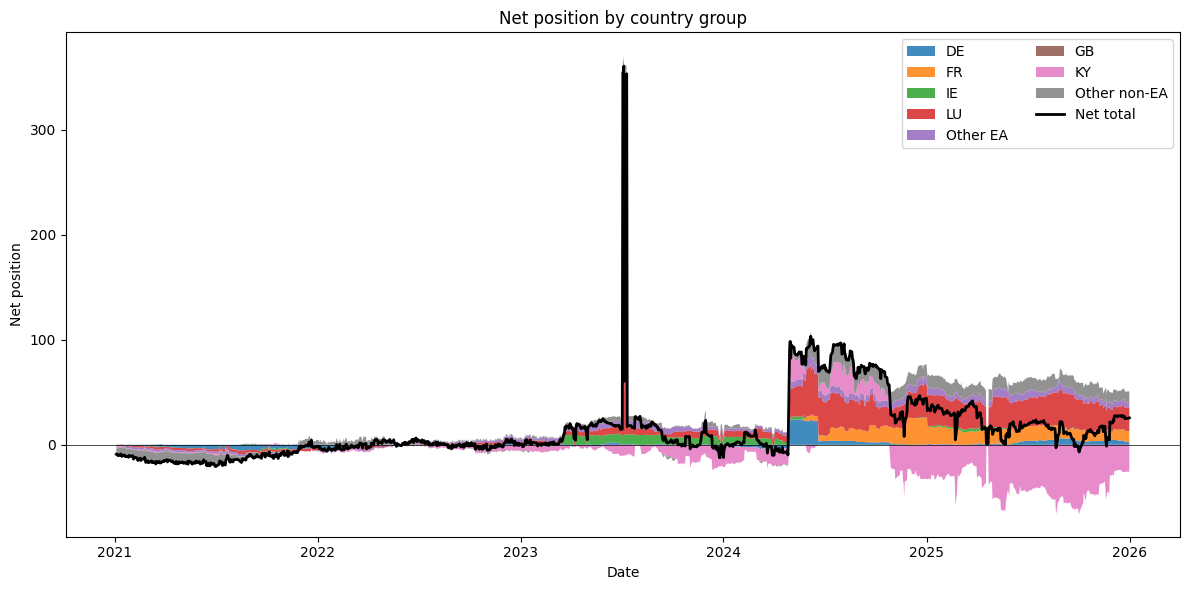

In [152]:
import matplotlib.pyplot as plt
import pandas as pd

# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

# Countries shown individually
NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

df_us = df_us.copy()
df_us['group'] = df_us['fund_country'].map(bucket)

# Pivot to wide format, with a fixed column order
order = ['DE', 'FR', 'IE', 'LU', 'Other EA', 'GB', 'KY', 'Other non-EA']
pivot = (
    df_us.pivot_table(
        index='business_date',
        columns='group',
        values='net_pos',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=order, fill_value=0)
    .sort_index()
)

# Split positive and negative contributions
pos = pivot.clip(lower=0)
neg = pivot.clip(upper=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Use a consistent color per group across both stacks
colors = plt.cm.tab10.colors[:len(order)]

ax.stackplot(pos.index, pos.T, labels=pos.columns, colors=colors, alpha=0.85)
ax.stackplot(neg.index, neg.T, colors=colors, alpha=0.85)  # no labels, shared colors

# Net total line
total = pivot.sum(axis=1)
ax.plot(total.index, total, color='black', linewidth=2, label='Net total')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Net position')
ax.set_title('Net position by country group')
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

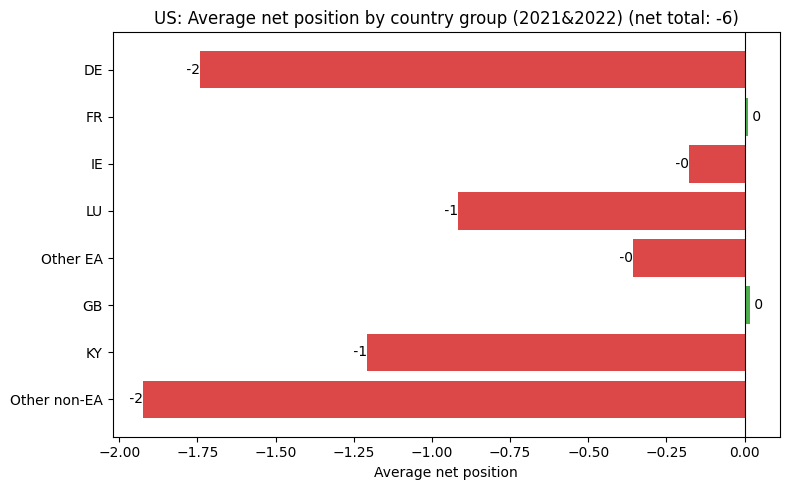

In [153]:
import matplotlib.pyplot as plt
import pandas as pd

# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']
ORDER = ['DE', 'FR', 'IE', 'LU', 'Other EA', 'GB', 'KY', 'Other non-EA']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

# Group into buckets and average over time
df_plot = df_us[df_us['business_date']< '2023-01-01'].copy()
df_plot['group'] = df_plot['fund_country'].map(bucket)

# First sum across countries within each (date, group), then average across dates
summary = (
    df_plot.groupby(['business_date', 'group'])['net_pos'].sum()
    .groupby('group').mean()
    .reindex(ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['tab:green' if v >= 0 else 'tab:red' for v in summary]
ax.barh(summary.index, summary.values, color=colors, alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Average net position')
ax.set_title(f'US: Average net position by country group (2021&2022) (net total: {summary.sum():,.0f})')

for i, v in enumerate(summary.values):
    ax.text(v, i, f' {v:,.0f}', va='center',
            ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.show()

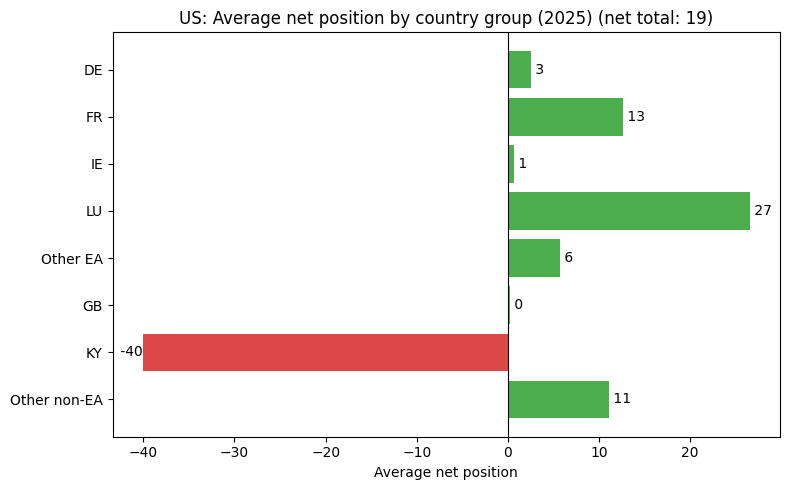

In [154]:
import matplotlib.pyplot as plt
import pandas as pd

# Euro area country codes (ISO 3166-1 alpha-2)
EA_COUNTRIES = {
    'AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK'
}

NAMED = ['DE', 'FR', 'IE', 'LU', 'GB', 'KY']
ORDER = ['DE', 'FR', 'IE', 'LU', 'Other EA', 'GB', 'KY', 'Other non-EA']

def bucket(country):
    if country in NAMED:
        return country
    if country in EA_COUNTRIES:
        return 'Other EA'
    return 'Other non-EA'

# Group into buckets and average over time
df_plot = df_us[df_us['business_date'] > '2025-01-01'].copy()
df_plot['group'] = df_plot['fund_country'].map(bucket)

# First sum across countries within each (date, group), then average across dates
summary = (
    df_plot.groupby(['business_date', 'group'])['net_pos'].sum()
    .groupby('group').mean()
    .reindex(ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['tab:green' if v >= 0 else 'tab:red' for v in summary]
ax.barh(summary.index, summary.values, color=colors, alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Average net position')
ax.set_title(f'US: Average net position by country group (2025) (net total: {summary.sum():,.0f})')

for i, v in enumerate(summary.values):
    ax.text(v, i, f' {v:,.0f}', va='center',
            ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.show()

## SFTDS share

In [179]:
df = pd.read_csv('key dataframe\\sftds_dataframe.csv', index_col = 0)

In [181]:
hedge_funds = pd.read_csv('key dataframe\\overlap_hedge_funds.csv')

In [182]:
hf_overlap = tuple(hedge_funds['entity_id'].unique())

In [183]:
df.loc[(df['entity_id'].isin(hf_overlap)), 'overlap'] = 1
df['overlap'].fillna(0, inplace = True)

In [187]:
df['net_pos'] = (df['borrowing_volume'] - df['lending_volume'])/1e9

In [189]:
df['business_date'] = pd.to_datetime(df['business_date'])

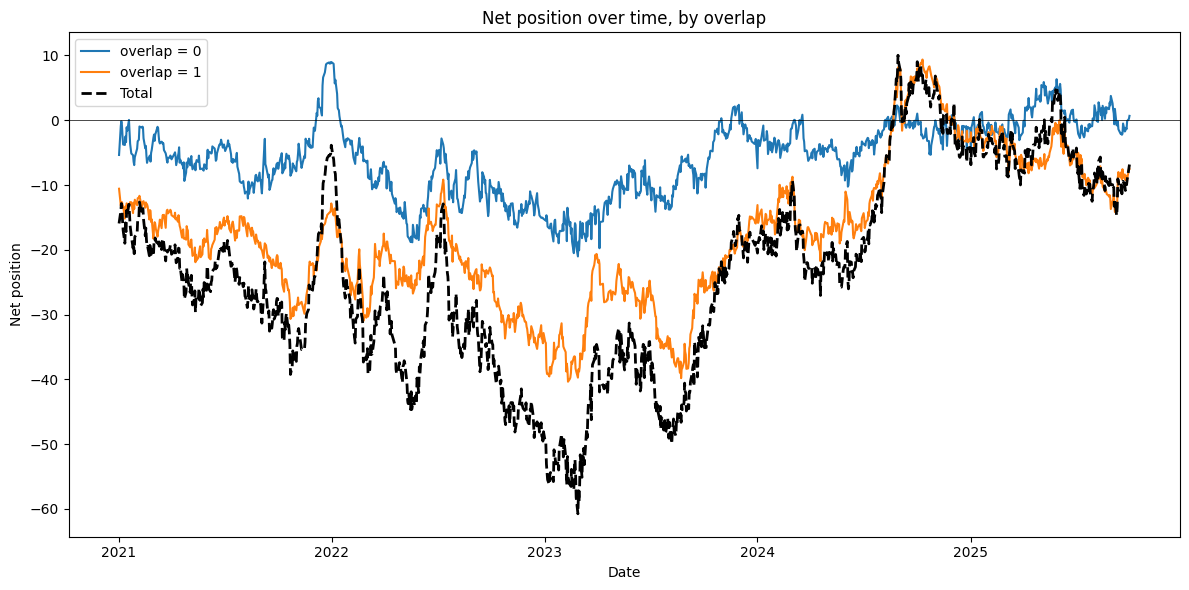

In [192]:
import matplotlib.pyplot as plt

# Sum net_pos per date per overlap group
ts = (
    df[df['security_isin'].str[:2] == 'DE'].groupby(['business_date', 'overlap'])['net_pos']
    .sum()
    .unstack('overlap')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ts.index, ts[0], label='overlap = 0', linewidth=1.5)
ax.plot(ts.index, ts[1], label='overlap = 1', linewidth=1.5)
ax.plot(ts.index, ts.sum(axis=1), label='Total', color='black', linewidth=2, linestyle='--')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Net position')
ax.set_title('Net position over time, by overlap')
ax.legend()
plt.tight_layout()
plt.show()

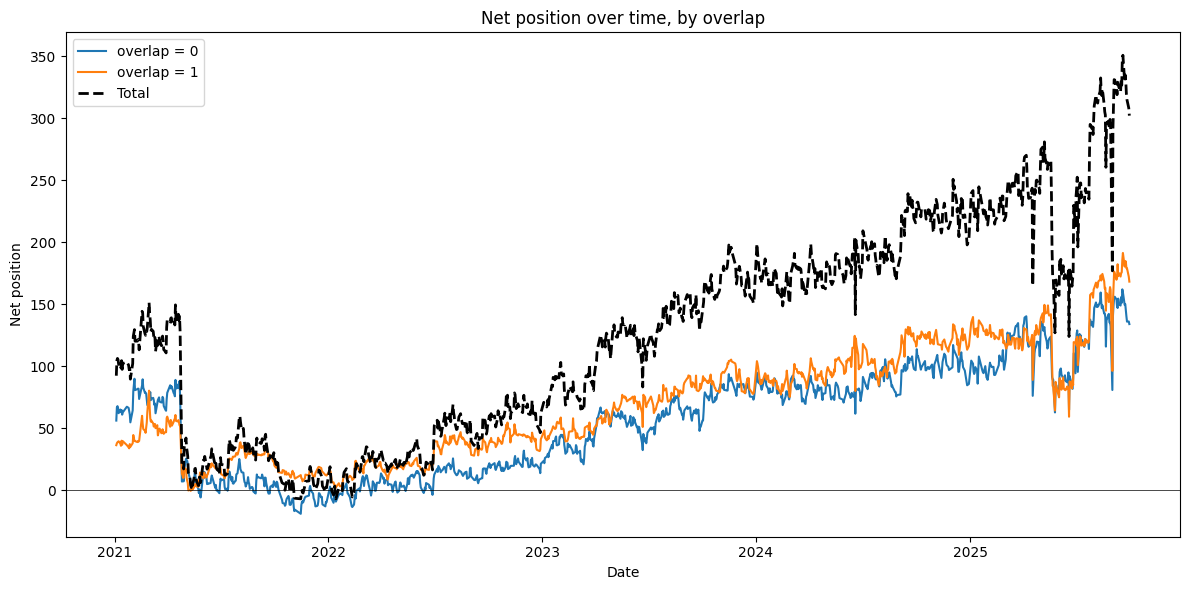

In [196]:
import matplotlib.pyplot as plt

# Sum net_pos per date per overlap group
ts = (
    df[df['security_isin'].str[:2] == 'US'].groupby(['business_date', 'overlap'])['net_pos']
    .sum()
    .unstack('overlap')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ts.index, ts[0], label='overlap = 0', linewidth=1.5)
ax.plot(ts.index, ts[1], label='overlap = 1', linewidth=1.5)
ax.plot(ts.index, ts.sum(axis=1), label='Total', color='black', linewidth=2, linestyle='--')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Net position')
ax.set_title('Net position over time, by overlap')
ax.legend()
plt.tight_layout()
plt.show()

# EMIR foreign dealers

In [2]:
dealers = pd.read_excel('Data\\bbg_sector.xlsx')

In [3]:
dealers['sector'].value_counts()

sector
IF_EA           974
IF_NONEA        915
MFI_EA          295
ICPF_EA         215
MFI_NONEA       115
DEALER_NONEA     69
OFI_EA           69
MMF_EA           66
ICPF_NONEA       55
GOV_EA           45
DEALER_EA        40
NFC_EA           36
OFI_NONEA        30
CB_NONEA         18
GOV_NONEA        11
CB_EA             5
MMF_NONEA         4
NFC_NONEA         3
Name: count, dtype: int64

In [4]:
nonea_dealers = tuple(dealers['LEI'][dealers['sector'] == 'DEALER_NONEA'].unique())

## UK overall

In [23]:
# Data prep
query = f"""

SELECT reference_period as business_date, notional_leg1_currency as currency, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'BANK')
AND other_cpty_id_country_code_gleif = 'GB' 
AND reporting_cpty_id = '529900LN3S50JPU47S06'
AND notional_leg1 <= 1e11
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\95887627.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [24]:
# Data prep
query = f"""


SELECT reference_period as business_date, notional_currency1 as currency,  counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'BANK')
AND other_cpty_id_country_code IN ('GB') 
AND reporting_cpty_id = '529900LN3S50JPU47S06'
AND notional <= 1e11
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\2150590364.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [25]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [26]:
df_pivoted = df_emir.pivot_table(
    index=['business_date', 'currency'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [27]:
# data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND borrower_country_residence = 'KY'
    AND s_borrower.sector = 'IF'
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
GROUP BY s.business_date
ORDER BY s.business_date

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\596304140.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [28]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND lender_country_residence = 'KY'
    AND s_lender.sector = 'IF'
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
GROUP BY s.business_date
ORDER BY s.business_date
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\3580325312.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [29]:
df = df_borrowing.merge(df_lending, on= ['business_date'], how = 'outer')

In [30]:
df_pivoted['business_date'] = pd.to_datetime(df_pivoted['business_date'])

In [31]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [32]:
df_full = df.merge(df_pivoted[['business_date', 'vol_sell', 'vol_buy']], on = 'business_date', how = 'left')

In [33]:
df_full['net_repo'] = (df_full['borrowing_volume'] - df_full['lending_volume'])/1e9

In [34]:
df_full['net_futures'] = (df_full['vol_sell'] - df_full['vol_buy'])/1e9

In [35]:
df_full.head()

,business_date,borrowing_volume,lending_volume,vol_sell,vol_buy,net_repo,net_futures
0,2021-01-01,3.605286e+10,5.972748e+10,NaN,NaN,-23.674614,NaN
1,2021-01-04,4.302250e+10,6.947939e+10,21300000.0,31400000.0,-26.456888,-0.0101
2,2021-01-05,4.254048e+10,7.048148e+10,22200000.0,30900000.0,-27.941001,-0.0087
3,2021-01-06,4.634265e+10,7.449417e+10,22200000.0,30900000.0,-28.151522,-0.0087
4,2021-01-07,4.956200e+10,8.058751e+10,20400000.0,32800000.0,-31.025502,-0.0124


In [36]:
df_full[['business_date', 'net_futures', 'net_repo']].to_excel('UK_all.xlsx')

## Non-EA dealers

In [37]:
# Data prep
query = f"""

SELECT reference_period as business_date, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'BANK')
AND other_cpty_id IN {nonea_dealers}
AND reporting_cpty_id = '529900LN3S50JPU47S06'
GROUP BY reference_period, direction
ORDER BY reference_period, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\1096557591.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [38]:
# Data prep
query = f"""


SELECT reference_period as business_date, counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'BANK')
AND other_cpty_id IN {nonea_dealers}
AND reporting_cpty_id = '529900LN3S50JPU47S06'
GROUP BY reference_period, direction
ORDER BY reference_period, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\1113581367.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [39]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [40]:
df_pivoted = df_emir.pivot_table(
    index=['business_date'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [41]:
# data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND borrower_country_residence = 'KY'
    AND s_borrower.sector = 'IF'
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
GROUP BY s.business_date
ORDER BY s.business_date

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\596304140.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [42]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND lender_country_residence = 'KY'
    AND s_lender.sector = 'IF'
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
GROUP BY s.business_date
ORDER BY s.business_date
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\3580325312.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [43]:
df = df_borrowing.merge(df_lending, on= ['business_date'], how = 'outer')

In [44]:
df_pivoted['business_date'] = pd.to_datetime(df_pivoted['business_date'])

In [45]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [46]:
df_full = df.merge(df_pivoted[['business_date', 'vol_sell', 'vol_buy']], on = 'business_date', how = 'left')

In [48]:
df_full['net_repo'] = (df_full['borrowing_volume'] - df_full['lending_volume'])/1e9

In [49]:
df_full['net_futures'] = (df_full['vol_sell'] - df_full['vol_buy'])/1e9

In [50]:
df_full.head()

,business_date,borrowing_volume,lending_volume,vol_sell,vol_buy,net_repo,net_futures
0,2021-01-01,3.605286e+10,5.972748e+10,NaN,NaN,-23.674614,NaN
1,2021-01-04,4.302250e+10,6.947939e+10,10300000.0,13400000.0,-26.456888,-0.0031
2,2021-01-05,4.254048e+10,7.048148e+10,10700000.0,13100000.0,-27.941001,-0.0024
3,2021-01-06,4.634265e+10,7.449417e+10,10500000.0,13300000.0,-28.151522,-0.0028
4,2021-01-07,4.956200e+10,8.058751e+10,9500000.0,14400000.0,-31.025502,-0.0049


In [51]:
df_full[['business_date', 'net_futures', 'net_repo']].to_excel('nonEA_dealers.xlsx')

## UK dealers

In [52]:
# Data prep
query = f"""

SELECT reference_period as business_date, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'BANK')
AND other_cpty_id IN {nonea_dealers}
AND other_cpty_id_country_code_gleif = 'GB' 
AND reporting_cpty_id = '529900LN3S50JPU47S06'
GROUP BY reference_period, direction
ORDER BY reference_period, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\1708547744.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [53]:
# Data prep
query = f"""


SELECT reference_period as business_date, counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (s_entity.sector = 'BANK')
AND other_cpty_id IN {nonea_dealers}
AND other_cpty_id_country_code IN ('GB') 
AND reporting_cpty_id = '529900LN3S50JPU47S06'
GROUP BY reference_period, direction
ORDER BY reference_period, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\2133183326.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [54]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [55]:
df_pivoted = df_emir.pivot_table(
    index=['business_date'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [56]:
# data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND borrower_country_residence = 'KY'
    AND s_borrower.sector = 'IF'
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
GROUP BY s.business_date
ORDER BY s.business_date

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\596304140.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [57]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.central_clearing = 'non-cleared'
    AND s.gnlcoll = 'SPEC'
    AND lender_country_residence = 'KY'
    AND s_lender.sector = 'IF'
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
GROUP BY s.business_date
ORDER BY s.business_date
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21392\3580325312.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [58]:
df = df_borrowing.merge(df_lending, on= ['business_date'], how = 'outer')

In [59]:
df_pivoted['business_date'] = pd.to_datetime(df_pivoted['business_date'])

In [60]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [61]:
df_full = df.merge(df_pivoted[['business_date', 'vol_sell', 'vol_buy']], on = 'business_date', how = 'left')

In [62]:
df_full['net_repo'] = (df_full['borrowing_volume'] - df_full['lending_volume'])/1e9

In [63]:
df_full['net_futures'] = (df_full['vol_sell'] - df_full['vol_buy'])/1e9

In [64]:
df_full.head()

,business_date,borrowing_volume,lending_volume,vol_sell,vol_buy,net_repo,net_futures
0,2021-01-01,3.605286e+10,5.972748e+10,NaN,NaN,-23.674614,NaN
1,2021-01-04,4.302250e+10,6.947939e+10,10200000.0,12000000.0,-26.456888,-0.0018
2,2021-01-05,4.254048e+10,7.048148e+10,10600000.0,11700000.0,-27.941001,-0.0011
3,2021-01-06,4.634265e+10,7.449417e+10,10400000.0,11900000.0,-28.151522,-0.0015
4,2021-01-07,4.956200e+10,8.058751e+10,9400000.0,13000000.0,-31.025502,-0.0036


In [65]:
df_full[['business_date', 'net_futures', 'net_repo']].to_excel('UK_dealers.xlsx')

## Aggregated

In [5]:
# Data prep
query = f"""

SELECT reference_period as business_date, notional_leg1_currency as currency, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'BANK' OR s_entity.sector = 'OFI') AND other_cpty_id_country_code_gleif = 'GB') OR other_cpty_id_country_code_gleif = 'KY')
AND ccp_id = '529900LN3S50JPU47S06'
AND notional_leg1 <= 5e10
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\3910689807.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [6]:
# 94% of volumes are accounted for by the case when eurex is not just the CCP but also the reporter
1445798308486950/1542281038818838

0.9374415376293677

In [7]:
# Data prep
query = f"""


SELECT reference_period as business_date, notional_currency1 as currency,  counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'BANK' OR s_entity.sector = 'OFI') AND other_cpty_id_country_code = 'GB') OR other_cpty_id_country_code = 'KY')
AND ccp_id = '529900LN3S50JPU47S06'
AND notional <= 5e10
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\901412727.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [8]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [9]:
df_pivoted = df_emir.pivot_table(
    index=['business_date', 'currency'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [10]:
# data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND ((s_borrower.sector = 'BANK' AND borrower_country = 'GB') OR borrower_country_residence = 'KY')
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
    AND assttp_scty_issr_sector_riad = 'S1311'
GROUP BY s.business_date
ORDER BY s.business_date

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\3015081106.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [11]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND ((s_lender.sector = 'BANK' AND lender_country = 'GB') OR lender_country_residence = 'KY')
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE', 'IT', 'ES', 'FR')
    AND assttp_scty_issr_sector_riad = 'S1311'
GROUP BY s.business_date
ORDER BY s.business_date
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\1286324331.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [12]:
df = df_borrowing.merge(df_lending, on= ['business_date'], how = 'outer')

In [13]:
df_pivoted['business_date'] = pd.to_datetime(df_pivoted['business_date'])

In [14]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [15]:
df_full = df.merge(df_pivoted[['business_date', 'vol_sell', 'vol_buy']], on = 'business_date', how = 'left')

In [16]:
df_full['net_repo'] = (df_full['borrowing_volume'] - df_full['lending_volume'])/1e9

In [17]:
df_full['net_futures'] = (df_full['vol_sell'] - df_full['vol_buy'])/1e9

In [18]:
df_full.tail()

,business_date,borrowing_volume,lending_volume,vol_sell,vol_buy,net_repo,net_futures
1208,2025-09-24,5.730818e+11,5.289142e+11,1.932303e+11,2.280448e+11,44.167566,-34.814509
1209,2025-09-25,5.649439e+11,5.237521e+11,1.952816e+11,2.270998e+11,41.191763,-31.818141
1210,2025-09-26,5.702573e+11,5.240960e+11,1.921394e+11,2.298169e+11,46.161295,-37.677479
1211,2025-09-29,5.669423e+11,5.296376e+11,1.884501e+11,2.238562e+11,37.304615,-35.406134
1212,2025-09-30,5.606908e+11,5.379803e+11,1.895070e+11,2.245197e+11,22.710458,-35.012692


In [22]:
df_full[['business_date', 'net_futures', 'net_repo']].to_csv('Data\\broadest_netpositions_limitations.csv', index = False)

### only for germany

In [51]:
index_names = tuple(['EURX ESCHATZ', 'EURO SCHATZ', 'Euro Schatz', 'Euro Schatz-Future',
    'Euro-Schatz', 'EURO - SCHATZ', 'Euro Schatz -2 Year Bond',
    'Euro-Schatz-2-Year-Bond',
    'EURX EURBOBL', 'EURO BOBL', 'Euro Bobl -5 Year Bond', 'Euro-Bobl',
    'Euro-Bobl Futures (FGBM)', 'Euro-Bobl Futures',
    'Euro-Bobl-5-Year-Bond', 'Euro-Bobl 5yr 6%',
    'EURO BUND', '"EURX EUR-BUND"', 'Euro Bund -10 Year Bond', 'Euro-Bund',
    'Euro-Bund Futures', 'Euro bund', 'Euro Bund', 'BUND', 'Euro Bund-Future',
    'FGBL', 'EURO BUND FUTURES', 'EURO EU BOND EUROPEAN LT UND',
    'BUND FUTURES SEP24', 'BUND FUTURES DEC24', 'BUND FUTURES MAR25',
    'BUND FUTURES JUN25', 'FGBL MAR25 [FIXED INCOME FUTURES',
    'FGBL SI 20250606 PS', 'FGBL SI 20250908 PS', 'FGBL SI 20251208 PS',
    'Euro-Bund-10-Year-Bond', 'Euro-Bund 10yr 6%',
    '"EURX EURO-BUXL"', 'GERMAN GOVERNMENT BUXL  Bond',
    'Euro Buxl -15 - 30 Year Bond', 'Euro-Buxl Futures',
    'Euro Buxl Futures', 'Euro Buxl', 'Euro-Buxl',
    'Euro-Buxl-15-30-Year-Bond'])

In [ ]:
product_isin = tuple([
    'DE0009652669','DE0009652651','DE0009652644','DE0009652636',

    'DE000F2MGDC1','DE000F2Y2EY1','DE000F3A9ET3',
    'DE000F1B2NH5','DE000F1NGF61','DE000F1ZLHQ6','DE000F2MGDD9','DE000F2Y2EZ8','DE000F3A9EU1',
    'DE000F1B2NJ1','DE000F1NGF79','DE000F1ZLHR4','DE000F2MGDE7','DE000F2Y2E04','DE000F3A9EV9',
    'DE000F1B2NK9','DE000F1NGF87','DE000F1ZLHS2','DE000F2MGDF4','DE000F2Y2E12','DE000F3A9EW7',

    'DE000F0FSQN3','DE000F0FSQP8','DE000F0FSQQ6','DE000F0Q7BW2',
    'DE000F0Q7BV4','DE000F0Q7BU6','DE000F01NAD9','DE000F01NAF4',
    'DE000F1B2NG7','DE000F1NGF53','DE000F1ZLHP8',

    'DE0009652645','DE0009652648','DE000C75XMU8','DE000C75XMW4',
    'DE000C6YTCM4','DE000C5GTXB2','DE000C52GUE9',
    'DE000C52GUF6','DE000C52GUG4','DE000C52GUH2',
    'DE000C58EEG0','DE000C58EEH8','DE000C58EEJ4','DE000C58EEK2',
    'DE000C6EBR73','DE000C6EBR81','DE000C6EBR99','DE000C6EBRA7',
    'DE000C1T6JE8','DE000C1T6JF5','DE000C1T6JG3','DE000C1T6JH1',
    'DE000C6J0K11','DE000C6J0K29','DE000C6J0K37','DE000C6J0K45',
    'DE000C6R0452','DE000A3ETB78',

    'DE000C75XMV6','DE000C5GTXC0','DE000C5RQDB7','DE000C6R0460','DE000C6YTCN2','DE000C671E30',
    'DE000C7F2YB2','DE000C7PB9Z2','DE000C7X7UL6',

    'DE000C75XMX2','DE000F0FSQR4','DE000F01NAG2','DE000C5GTXE6','DE000C5RQDD3','DE000C6R0494',
    'DE000C6YTCQ5','DE000C671E55','DE000C7F2YD8','DE000C7PB918','DE000C7X7UN2',

    'DE000BU22049','DE000C5GTXD8','DE000C5RQDC5','DE000C6R0478','DE000C6YTCP7','DE000C671E48',
    'DE000C7F2YC0','DE000C7PB900','DE000C7X7UM4','DE000F01NAE7',

    'DE000BU2Z007','DE000C5RQDA9','DE000C671E22','DE000C7F2YA4','DE000C7PB9Y5','DE000C7X7UK8',
    'DE000F1NGF20','DE0009664581'
])

In [53]:
# Data prep
query = f"""

SELECT reference_period as business_date, notional_leg1_currency as currency, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'BANK' OR s_entity.sector = 'OFI') AND other_cpty_id_country_code_gleif = 'GB') OR other_cpty_id_country_code_gleif = 'KY')
AND ccp_id = '529900LN3S50JPU47S06'
AND notional_leg1 <= 5e10
AND (underlying_id IN {product_isin} OR product_isin IN {product_isin} OR underlying_index_name IN {index_names})
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\1647306820.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [54]:
# Data prep
query = f"""


SELECT reference_period as business_date, notional_currency1 as currency,  counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'BANK' OR s_entity.sector = 'OFI') AND other_cpty_id_country_code = 'GB') OR other_cpty_id_country_code = 'KY')
AND ccp_id = '529900LN3S50JPU47S06'
AND notional <= 5e10
AND (underlying_id IN {product_isin} OR product_id IN {product_isin} OR underlying_index_name IN {index_names})
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\1077422050.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [55]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [56]:
df_pivoted = df_emir.pivot_table(
    index=['business_date', 'currency'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [57]:
# data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND ((s_borrower.sector = 'BANK' AND borrower_country = 'GB') OR borrower_country_residence = 'KY')
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE')
    AND assttp_scty_issr_sector_riad = 'S1311'
GROUP BY s.business_date
ORDER BY s.business_date

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\3249520580.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [58]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND ((s_lender.sector = 'BANK' AND lender_country = 'GB') OR lender_country_residence = 'KY')
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('DE')
    AND assttp_scty_issr_sector_riad = 'S1311'
GROUP BY s.business_date
ORDER BY s.business_date
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\248058935.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [59]:
df = df_borrowing.merge(df_lending, on= ['business_date'], how = 'outer')

In [60]:
df_pivoted['business_date'] = pd.to_datetime(df_pivoted['business_date'])

In [61]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [62]:
df_full = df.merge(df_pivoted[['business_date', 'vol_sell', 'vol_buy']], on = 'business_date', how = 'left')

In [63]:
df_full['net_repo'] = (df_full['borrowing_volume'] - df_full['lending_volume'])/1e9

In [64]:
df_full['net_futures'] = (df_full['vol_sell'] - df_full['vol_buy'])/1e9

In [65]:
df_full[['business_date', 'net_futures', 'net_repo']].to_csv('Data\\DE_netpositions_limitations.csv', index = False)

### only for italy

In [66]:
index_names = tuple(['EURO-BTP LONGTERM ITA GOV BOND', 'Euro-BTP Italian Government Bond',
    'Euro BTP Futures', '"EUX EURO-BTP"', 'Long-Term Euro-BTP',
    'BTP FUTURES JUN24', 'BTP FUTURES SEP24', 'BTP FUTURES DEC24',
    'BTP FUTURES MAR25', 'BTP FUTURES JUN25', 'BTP FUTURES SEP25',
    'Euro-BTP-Italian-Government-Bond', 'Euro BTP Futures',
    'SHORT TERM EURO-BTP  bond', 'Short-Term Euro-BTP Italian Government Bond',
    'SHORT TERM BTP FUTURES', 'Short-Term Euro-BTP',
    'Short-Term-Euro-BTP-Italian-Government-Bond'])

In [67]:
product_isin = tuple([
    'DE000A0ZW3V8','DE000A1EZJ09',

    'DE000F1B2NF9','DE000F1NGF38','DE000F1ZLHN3',
    'DE000F2MGDA5','DE000F2Y2EW5','DE000F3A9ER7',

    'DE000F1B2NE2','DE000F1NGF46','DE000F1ZLHM5',
    'DE000F2MGDB3','DE000F2Y2EX3','DE000F3A9ES5',

    'DE000F0Q7BS0',

    'DE000C6YTCK8','DE000C5GTX90','DE000C5RQD86','DE000C52GUC3',
    'DE000C58EEE5','DE000C58EEF2',
    'DE000C6EBR57','DE000C6EBR65',
    'DE000C1T6JD0','DE000C6J0JZ3','DE000C6R0411','DE000C671E06',

    'DE000C75XMT0','DE000F0FSQM5','DE000F0Q7BT8','DE000F01NAC1',
    'DE000C5GTXA4','DE000C5RQD94','DE000C52GUD1','DE000C1T6JC2',
    'DE000C6J0K03','DE000C6R0437','DE000C6YTCL6','DE000C671E14',
    'DE000C7F2X93','DE000C7PB9X7',

    'DE000C75XMS2','DE000F0FSQL7','DE000F01NAB3',
    'DE000C7F2X85','DE000C7PB9W9','DE000C7X7UH4','DE000C7X7UJ0'
])

In [68]:
# Data prep
query = f"""

SELECT reference_period as business_date, notional_leg1_currency as currency, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'BANK' OR s_entity.sector = 'OFI') AND other_cpty_id_country_code_gleif = 'GB') OR other_cpty_id_country_code_gleif = 'KY')
AND ccp_id = '529900LN3S50JPU47S06'
AND notional_leg1 <= 5e10
AND (underlying_id IN {product_isin} OR product_isin IN {product_isin} OR underlying_index_name IN {index_names})
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\1647306820.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [69]:
# Data prep
query = f"""


SELECT reference_period as business_date, notional_currency1 as currency,  counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'BANK' OR s_entity.sector = 'OFI') AND other_cpty_id_country_code = 'GB') OR other_cpty_id_country_code = 'KY')
AND ccp_id = '529900LN3S50JPU47S06'
AND notional <= 5e10
AND (underlying_id IN {product_isin} OR product_id IN {product_isin} OR underlying_index_name IN {index_names})
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\1077422050.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [70]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [71]:
df_pivoted = df_emir.pivot_table(
    index=['business_date', 'currency'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [72]:
# data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND ((s_borrower.sector = 'BANK' AND borrower_country = 'GB') OR borrower_country_residence = 'KY')
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('IT')
    AND assttp_scty_issr_sector_riad = 'S1311'
GROUP BY s.business_date
ORDER BY s.business_date

"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\2596447129.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [73]:
# Data prep
query = f"""

SELECT 
    s.business_date,
    SUM(s.nominal_value) AS lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON s.lender_id = s_lender.id
WHERE s.nominal_ccy IN ('EUR', 'USD')
    AND s.business_date <= '2025-10-01'
    AND s.gnlcoll = 'SPEC'
    AND ((s_lender.sector = 'BANK' AND lender_country = 'GB') OR lender_country_residence = 'KY')
    AND security_type = 'GOVS'
    AND LEFT(security_isin, 2) IN ('IT')
    AND assttp_scty_issr_sector_riad = 'S1311'
GROUP BY s.business_date
ORDER BY s.business_date
"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\584501843.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [74]:
df = df_borrowing.merge(df_lending, on= ['business_date'], how = 'outer')

In [75]:
df_pivoted['business_date'] = pd.to_datetime(df_pivoted['business_date'])

In [76]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [77]:
df_full = df.merge(df_pivoted[['business_date', 'vol_sell', 'vol_buy']], on = 'business_date', how = 'left')

In [78]:
df_full['net_repo'] = (df_full['borrowing_volume'] - df_full['lending_volume'])/1e9

In [79]:
df_full['net_futures'] = (df_full['vol_sell'] - df_full['vol_buy'])/1e9

In [80]:
df_full[['business_date', 'net_futures', 'net_repo']].to_csv('Data\\IT_netpositions_limitations.csv', index = False)

# ICPFs for Andrea

In [81]:
ea_icpf = tuple(dealers['LEI'][dealers['sector'] == 'ICPF_EA'].unique())

In [83]:
# Data prep
query = f"""

SELECT reference_period as business_date, notional_leg1_currency as currency, CASE WHEN direction = 'MAKE' THEN 'SLLR' WHEN direction = 'TAKE' THEN 'BYER' ELSE direction END AS direction, SUM(notional_leg1) as vol
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND notional_leg1 < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional_leg1 > 0
AND notional_leg1_currency IN ("EUR")
AND LEFT(product_cfi, 3) = 'FFD'
AND (LEFT(underlying_id, 2) != 'EU' OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'IC' OR s_entity.sector = 'PF') AND other_cpty_id_country_code_gleif IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') ) OR reporting_cpty_id IN {ea_icpf})
AND notional_leg1 <= 5e10
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\3431477898.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [85]:
# Data prep
query = f"""


SELECT reference_period as business_date, notional_currency1 as currency,  counterparty_side as direction, SUM(notional) as vol
FROM crp_emir_ecb.emir_ecb_states_validated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_entity ON s.other_cpty_id = s_entity.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND notional < 1e18
AND asset_class = 'INTR'
AND contract_type = 'FUTR'
AND notional > 0
AND notional_currency1 IN ("EUR")
AND LEFT(product_clssfctn, 3) = 'FFD'
AND ((LEFT(underlying_id, 2) NOT IN ('EU', 'XC')) OR underlying_id IS NULL)
AND (underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR underlying_index_name IS NULL)
AND MONTH(maturity_date) IN (3, 6, 9, 12)
AND (((s_entity.sector = 'IC' OR s_entity.sector = 'PF') AND other_cpty_id_country_code IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') ) OR reporting_cpty_id IN {ea_icpf})
AND notional <= 5e10
GROUP BY reference_period, currency, direction
ORDER BY reference_period, currency, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_48544\668813048.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [86]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [87]:
df_pivoted = df_emir.pivot_table(
    index=['business_date', 'currency'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivoted.columns.name = None  # remove the 'direction' label on columns
df_pivoted = df_pivoted.rename(columns={'SLLR': 'vol_sell', 'BYER': 'vol_buy'})

In [88]:
df_pivoted.head()

,business_date,currency,vol_buy,vol_sell
0,2021-01-04,EUR,3.994718e+10,3.251563e+10
1,2021-01-05,EUR,4.099318e+10,3.673365e+10
2,2021-01-06,EUR,4.156541e+10,3.819957e+10
3,2021-01-07,EUR,4.139344e+10,3.813342e+10
4,2021-01-08,EUR,4.028031e+10,3.640854e+10


In [89]:
df_pivoted['net_futures'] = (df_pivoted['vol_buy'] - df_pivoted['vol_sell'])/1e9

In [90]:
df_pivoted.to_excel('test.xlsx')

# sector breakdown futures

In [2]:
german_futures = pd.read_csv('Data\\german_futures.csv', index_col = 0)

In [3]:
futures = tuple(german_futures['0'][german_futures['0'].isna() == False].unique())

In [4]:
hedge_funds = pd.read_csv('key dataframe\\overlap_hedge_funds.csv')

In [5]:
hfunds = tuple(hedge_funds['entity_id'].unique())

In [32]:
# Data prep
query = f"""

SELECT reference_period as business_date, CASE WHEN leg1_direction = 'MAKE' THEN 'SLLR' WHEN leg1_direction = 'TAKE' THEN 'BYER' ELSE leg1_direction END AS direction, SUM(leg1_notional_leg1) as vol, 
CASE WHEN leg1_other_cpty_id_country_code_gleif IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') THEN 'EA' ELSE 'non-EA' END AS other_country,
CASE WHEN leg1_reporting_cpty_id_country_code_gleif IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') THEN 'EA' ELSE 'non-EA' END AS reporter_country,
CASE 
    WHEN s_reporter.sector = 'BANK' THEN 'BANK' 
    WHEN s_reporter.sector = 'IC' OR s_reporter.sector = 'PF' THEN 'ICPF'
    WHEN leg1_reporting_cpty_id IN {hfunds} OR s_reporter.if_strategy = 'Hedge' THEN 'HF'
    WHEN s_reporter.subsector = 'UCIT' THEN 'UCIT'
    WHEN s_reporter.sector = 'IF' THEN 'IF'
    WHEN s_reporter.sector = 'GOVT' THEN 'GOVT'
    WHEN s_reporter.sector = 'OFI' THEN 'OFI'
    ELSE 'Other'
END as reporter_sector,
CASE 
    WHEN s_other.sector = 'BANK' THEN 'BANK' 
    WHEN s_other.sector = 'IC' OR s_other.sector = 'PF' THEN 'ICPF'
    WHEN leg1_other_cpty_id IN {hfunds} OR s_other.if_strategy = 'Hedge' THEN 'HF'
    WHEN s_other.sector = 'IF' THEN 'IF'
    WHEN s_other.sector = 'GOVT' THEN 'GOVT'
    WHEN s_other.sector = 'OFI' THEN 'OFI'
    ELSE 'Other'
END as other_sector
FROM crp_emir_refit_ecb.emir_refit_ecb_trade_states_deduplicated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_reporter ON s.leg1_reporting_cpty_id = s_reporter.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_other ON s.leg1_other_cpty_id = s_other.id
WHERE reference_period >= '2024-04-29'
AND reference_period <= '2025-12-31'
AND leg1_asset_class = 'INTR'
AND leg1_contract_type = 'FUTR'
AND leg1_notional_leg1 > 0
AND leg1_notional_leg1_currency IN ("EUR")
AND LEFT(leg1_product_cfi, 3) = 'FFD'
AND (LEFT(leg1_underlying_id, 2) != 'EU' OR leg1_underlying_id IS NULL)
AND (leg1_underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR leg1_underlying_index_name IS NULL)
AND MONTH(leg1_maturity_date) IN (3, 6, 9, 12)
AND leg1_product_isin IN {futures}
AND leg1_notional_leg1 <= 1e11
GROUP BY reference_period, reporter_country, other_country, reporter_sector, other_sector, direction
ORDER BY reference_period, reporter_country, other_country, reporter_sector, other_sector, direction

"""

df_emir_refit = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21928\973073362.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_refit = pd.read_sql_query(query, cnxn)


In [33]:
# Data prep
query = f"""


SELECT reference_period as business_date, leg1_counterparty_side as direction, SUM(leg1_notional) as vol, 
CASE WHEN leg1_other_cpty_id_country_code IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') THEN 'EA' ELSE 'non-EA' END AS other_country,
CASE WHEN leg1_reporting_cpty_id_country_code IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') THEN 'EA' ELSE 'non-EA' END AS reporter_country,
CASE 
    WHEN s_reporter.sector = 'BANK' THEN 'BANK' 
    WHEN s_reporter.sector = 'IC' OR s_reporter.sector = 'PF' THEN 'ICPF'
    WHEN leg1_reporting_cpty_id IN {hfunds} OR s_reporter.if_strategy = 'Hedge' THEN 'HF'
    WHEN s_reporter.subsector = 'UCIT' THEN 'UCIT'
    WHEN s_reporter.sector = 'IF' THEN 'IF'
    WHEN s_reporter.sector = 'GOVT' THEN 'GOVT'
    WHEN s_reporter.sector = 'OFI' THEN 'OFI'
    ELSE 'Other'
END as reporter_sector,
CASE 
    WHEN s_other.sector = 'BANK' THEN 'BANK' 
    WHEN s_other.sector = 'IC' OR s_other.sector = 'PF' THEN 'ICPF'
    WHEN leg1_other_cpty_id IN {hfunds} OR s_other.if_strategy = 'Hedge' THEN 'HF'
    WHEN s_other.sector = 'IF' THEN 'IF'
    WHEN s_other.sector = 'GOVT' THEN 'GOVT'
    WHEN s_other.sector = 'OFI' THEN 'OFI'
    ELSE 'Other'
END as other_sector
FROM crp_emir_ecb.emir_ecb_states_deduplicated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_reporter ON s.leg1_reporting_cpty_id = s_reporter.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_other ON s.leg1_other_cpty_id = s_other.id
WHERE reference_period >= '2021-01-04'
AND reference_period <= '2024-04-29'
AND leg1_asset_class = 'INTR'
AND leg1_contract_type = 'FUTR'
AND leg1_notional > 0
AND leg1_notional_currency1 IN ("EUR")
AND LEFT(leg1_product_clssfctn, 3) = 'FFD'
AND ((LEFT(leg1_underlying_id, 2) NOT IN ('EU', 'XC')) OR leg1_underlying_id IS NULL)
AND (leg1_underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR leg1_underlying_index_name IS NULL)
AND MONTH(leg1_maturity_date) IN (3, 6, 9, 12)
AND leg1_product_id IN {futures}
AND leg1_notional <= 1e11
GROUP BY reference_period, reporter_country, other_country, reporter_sector, other_sector, direction
ORDER BY reference_period, reporter_country, other_country, reporter_sector, other_sector, direction


"""

df_emir_old = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21928\608327903.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emir_old = pd.read_sql_query(query, cnxn)


In [34]:
df_emir = pd.concat([df_emir_refit, df_emir_old]).drop_duplicates().reset_index(drop=True)

In [35]:
df_emir['other_sector'].unique()

array(['BANK', 'GOVT', 'HF', 'ICPF', 'IF', 'OFI', 'Other'], dtype=object)

In [36]:
df_emir.columns

Index(['business_date', 'direction', 'vol', 'other_country',
       'reporter_country', 'reporter_sector', 'other_sector'],
      dtype='object')

In [37]:
# Build the reporter-side view
df_reporter = df_emir[['business_date', 'reporter_sector', 'reporter_country', 'direction', 'vol']].copy()
df_reporter = df_reporter.rename(columns={
    'reporter_sector': 'sector',
    'reporter_country': 'country'
})
# Reporter's direction is as-reported
df_reporter['direction'] = df_reporter['direction'].map({'BYER': 'long_pos', 'SLLR': 'short_pos'})

# Build the other-side view
df_other = df_emir[['business_date', 'other_sector', 'other_country', 'direction', 'vol']].copy()
df_other = df_other.rename(columns={
    'other_sector': 'sector',
    'other_country': 'country'
})
# Other counterparty's direction is the OPPOSITE of what the reporter reported
df_other['direction'] = df_other['direction'].map({'BYER': 'short_pos', 'SLLR': 'long_pos'})

# Stack
df_emir = pd.concat([df_reporter, df_other], ignore_index=True)

In [38]:
df_emir['sector'] = df_emir['sector'] + '_' + df_emir['country']

In [39]:
df_emir.sample(5)

,business_date,sector,country,direction,vol
294146,2021-10-08,BANK_non-EA,non-EA,long_pos,1.122440e+10
292485,2021-09-23,IF_non-EA,non-EA,long_pos,7.000000e+05
327798,2022-08-25,Other_non-EA,non-EA,long_pos,1.545450e+06
390115,2024-03-25,BANK_non-EA,non-EA,short_pos,2.114335e+10
112649,2022-03-02,ICPF_EA,EA,short_pos,1.886548e+08


In [40]:
# Pivot
df_emir = df_emir.pivot_table(
    index=['business_date', 'sector'],
    columns='direction',
    values='vol',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_emir.columns.name = None

In [41]:
df_emir['net'] = (df_emir['long_pos'] - df_emir['short_pos'])/1e9

In [42]:
df_emir.to_csv('Data\\sector_breakdown_german_futures.csv', index= False)

In [17]:
ea_countries = "('FR','DE','LU','CY','IE','NL','ES','IT','PT','AT','FI','BE','SI','GR','EE','LT','HR','MT','SK','LV')"

base_filters = f"""
    WHERE reference_period >= '2021-01-04'
      AND reference_period <= '2024-04-29'
      AND leg1_asset_class = 'INTR'
      AND leg1_contract_type = 'FUTR'
      AND leg1_notional > 0
      AND leg1_notional_currency1 = 'EUR'
      AND LEFT(leg1_product_clssfctn, 3) = 'FFD'
      AND ((LEFT(leg1_underlying_id, 2) NOT IN ('EU', 'XC')) OR leg1_underlying_id IS NULL)
      AND (leg1_underlying_index_name NOT IN ('United States SOFR Secured Overnight Financing Rat', 'FEDERAL FUNDS EFFECTIVE RATE US') OR leg1_underlying_index_name IS NULL)
      AND MONTH(leg1_maturity_date) IN (3, 6, 9, 12)
      AND leg1_product_id IN {futures}
      AND leg1_notional <= 1e11
"""

In [47]:
# Reporter is EA-IF
query_reporter = f"""
SELECT leg1_reporting_cpty_id AS entity_id, s_reporter.if_strategy AS strat, s_reporter.subsector as subsector
FROM crp_emir_ecb.emir_ecb_states_deduplicated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_reporter
    ON s.leg1_reporting_cpty_id = s_reporter.id
{base_filters}
  AND leg1_reporting_cpty_id_country_code IN {ea_countries}
  AND s_reporter.sector = 'IF'
  AND leg1_reporting_cpty_id NOT IN {hfunds}
  AND (s_reporter.if_strategy != 'Hedge' OR s_reporter.if_strategy IS NULL)
  AND reference_period = '2022-06-10'
"""

# Other is EA-IF
query_other = f"""
SELECT leg1_other_cpty_id AS entity_id, s_other.if_strategy AS strat, s_other.subsector as subsector
FROM crp_emir_ecb.emir_ecb_states_deduplicated s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20250328 s_other
    ON s.leg1_other_cpty_id = s_other.id
{base_filters}
  AND leg1_other_cpty_id_country_code IN {ea_countries}
  AND s_other.sector = 'IF'
  AND leg1_other_cpty_id NOT IN {hfunds}
  AND (s_other.if_strategy != 'Hedge' OR s_other.if_strategy IS NULL)
  AND reference_period = '2022-06-10'
"""

df_rep = pd.read_sql_query(query_reporter, cnxn)
df_oth = pd.read_sql_query(query_other, cnxn)

# Combine and dedupe across both sides
df_if_entities = pd.concat([df_rep, df_oth], ignore_index=True)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_21928\2153281620.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rep = pd.read_sql_query(query_reporter, cnxn)
C:\Users\hermesf\AppData\Local\Temp\ipykernel_21928\2153281620.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_oth = pd.read_sql_query(query_other, cnxn)


In [49]:
df_if_entities['entity_id'].value_counts().head(10)

entity_id
549300SNGS1IE6OCU692    176
635400PYFSHIJUQTP711    136
549300OMU0PTQULTMQ53    122
FQS4MV2D2R1KECM0PF58    114
635400OFQISYH6GFYJ61     88
25G4GTZJH41RFF2UMI28     70
5493007QU6WCZG2Q7C58     59
B8NQ04W7QR02KG80L882     48
OI6S1GHW540RHM8VHN12     36
6HEUCIAY9HUUBKL34B23     33
Name: count, dtype: int64

In [23]:
len(df_if_entities[df_if_entities['strat'].isna()])/len(df_if_entities)

0.07254550115355037

In [31]:
df_if_entities['subsector'].value_counts(dropna = False)

subsector
UCIT    4507
AIFD    2707
None     556
AM        32
Name: count, dtype: int64